## 1. Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)

print('Ready')

Ready


## 2. Load Data

In [24]:
df = pd.read_csv('sensor6.csv', parse_dates=['date'])
df.rename(columns={'6': 'y', 'date': 'ds'}, inplace=True)
df = df.sort_values('ds').reset_index(drop=True)
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df.dropna(subset=['y'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape: {df.shape}  |  {df["ds"].min().date()} -> {df["ds"].max().date()}')

Shape: (1250, 6)  |  2017-05-07 -> 2020-10-07


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ds          1250 non-null   datetime64[ns]
 1   y           1250 non-null   float64       
 2   temp        1250 non-null   float64       
 3   wind_speed  1250 non-null   float64       
 4   humidity    1250 non-null   float64       
 5   pressure    1250 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 58.7 KB


## 3. Feature Engineering (Daily Level)

In [26]:
df

,ds,y,temp,wind_speed,humidity,pressure
0,2017-05-07,37.25,13.9,15.8,72.46,914.74
1,2017-05-08,40.50,16.4,10.8,60.54,913.49
2,2017-05-09,43.75,17.9,15.3,52.08,912.98
3,2017-05-10,47.00,19.1,9.0,48.75,911.27
4,2017-05-11,29.00,17.9,23.2,54.42,915.86
...,...,...,...,...,...,...
1245,2020-10-03,28.00,12.5,8.0,46.75,916.87
1246,2020-10-04,21.00,13.0,5.9,38.79,917.59
1247,2020-10-05,20.00,13.1,11.2,32.88,915.87
1248,2020-10-06,18.00,6.2,14.8,59.92,920.29


In [27]:
train_df = df[(df['ds'] >= '2017-04-21') & (df['ds'] < '2019-06-01')].reset_index(drop=True)
test_df = df[(df['ds'] >= '2019-06-01') & (df['ds'] < '2019-07-01')].reset_index(drop=True)

'''def build_features(df):
    d = df.copy()
    
    for lag in [1, 2, 3, 7, 14,30]:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    
    y_past = d['y'].shift(1)
    
    d['ewm_7'] = y_past.ewm(span=7).mean()
    d['ewm_3'] = y_past.ewm(span=3).mean()
    
    d['rolling_7'] = y_past.rolling(7).mean()
    d['rolling_3'] = y_past.rolling(3).mean()
    d['rolling_14'] = y_past.rolling(14).mean()
    
    d['month'] = d['ds'].dt.month
    d['dayofyear'] = d['ds'].dt.dayofyear

    d['month_sin'] = np.sin(2 * np.pi * d['month']/12)
    d['month_cos'] = np.cos(2 * np.pi * d['month']/12)


    d['tem_lag_1'] = d['temp'].shift(1)
    
    return d'''


def build_features(df):

    d = df[['ds', 'y']].copy()
    for lag in [1, 2, 3, 7, 14,30]:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    y_past = d['y'].shift(1)

    d['ewm_7'] = y_past.ewm(span=7).mean()
    d['ewm_3'] = y_past.ewm(span=3).mean()
    d['ewm_14'] = y_past.ewm(span=14).mean()
    d['ewm_30'] = y_past.ewm(span=30).mean()
   
    d['rolling_7'] = y_past.rolling(7).mean()
    d['rolling_14'] = y_past.rolling(14).mean()
    d['rolling_30'] = y_past.rolling(30).mean()

    d['month'] = d['ds'].dt.month
    d['dayofweek'] = d['ds'].dt.dayofweek
    d['dayofyear'] = d['ds'].dt.dayofyear

    return d


df_with_features = build_features(df)
df_with_features.dropna(inplace=True)

feat_train = df_with_features[(df_with_features['ds'] >= '2017-06-06') & 
                              (df_with_features['ds'] < '2018-07-26')]

feat_test = df_with_features[(df_with_features['ds'] >= '2018-07-26') & 
                             (df_with_features['ds'] < '2018-09-24')]

print(f'Train shape: {feat_train.shape}')
print(f'Test shape: {feat_test.shape}')

Train shape: (415, 18)
Test shape: (60, 18)


In [28]:
df_with_features.columns

Index(['ds', 'y', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
       'ewm_7', 'ewm_3', 'ewm_14', 'ewm_30', 'rolling_7', 'rolling_14',
       'rolling_30', 'month', 'dayofweek', 'dayofyear'],
      dtype='object')

In [29]:
df_with_features.isna().sum().sum()

np.int64(0)

## 4. Metrics Helper

In [30]:
def get_metrics(y_true, y_pred):
    yt = np.array(y_true, dtype=float)
    yp = np.array(y_pred, dtype=float)
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp) * 100

    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2}

print('Metrics function ready')

Metrics function ready


## 5. Define Feature Columns

In [31]:
'''FEATURE_COLS = ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
                'ewm_7', 'ewm_14', 'rolling_7', 'rolling_14', 'rolling_30','ewm_3', 'ewm_30', 'rolling_3','diff_1', 'velocity', 'rolling_std_7', 'month_sin', 
                'month_cos', 'day_sin', 'day_cos', 'expanding_mean',
                'month', 'dayofweek', 'dayofyear']'''

FEATURE_COLS = [ 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
       'ewm_7', 'ewm_3', 'ewm_14', 'ewm_30', 'rolling_7', 'rolling_14',
       'rolling_30', 'month', 'dayofweek', 'dayofyear']
print(f'Features: {len(FEATURE_COLS)} columns')
print(f'  {FEATURE_COLS}')

Features: 16 columns
  ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'ewm_7', 'ewm_3', 'ewm_14', 'ewm_30', 'rolling_7', 'rolling_14', 'rolling_30', 'month', 'dayofweek', 'dayofyear']


## 6. Train Test Split 

In [32]:
'''X_train = feat_train[FEATURE_COLS].values
y_train = feat_train['y'].values'''

X_test = feat_test[FEATURE_COLS].values
y_test = feat_test['y'].values


X_train = feat_train[FEATURE_COLS].values.astype('float32') 
y_train = feat_train['y'].values.astype('float32')

## 7.1 Gradient boostimg method 

In [33]:
'''from sklearn.ensemble import GradientBoostingRegressor

GB_PARAMS = dict(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    min_samples_split = 5,
    min_samples_leaf  = 3,
    max_features      = 'sqrt',
    loss              = 'huber',
    random_state      = 42,
)

MODEL_NAME  = 'GradientBoosting'
MODEL_COLOR = '#9B59B6'

fold_results = []
fold_preds = []
lgb_imps = []


print(f'{MODEL_NAME} (Daily-level testing)')

model = GradientBoostingRegressor(**GB_PARAMS)

model.fit(X_train, y_train)

pred = np.clip(model.predict(X_test), 0, None)
m = get_metrics(y_test, pred)

print(m)

print(f'\nTraining complete!')'''

"from sklearn.ensemble import GradientBoostingRegressor\n\nGB_PARAMS = dict(\n    n_estimators      = 300,\n    learning_rate     = 0.05,\n    max_depth         = 4,\n    subsample         = 0.8,\n    min_samples_split = 5,\n    min_samples_leaf  = 3,\n    max_features      = 'sqrt',\n    loss              = 'huber',\n    random_state      = 42,\n)\n\nMODEL_NAME  = 'GradientBoosting'\nMODEL_COLOR = '#9B59B6'\n\nfold_results = []\nfold_preds = []\nlgb_imps = []\n\n\nprint(f'{MODEL_NAME} (Daily-level testing)')\n\nmodel = GradientBoostingRegressor(**GB_PARAMS)\n\nmodel.fit(X_train, y_train)\n\npred = np.clip(model.predict(X_test), 0, None)\nm = get_metrics(y_test, pred)\n\nprint(m)\n\nprint(f'\nTraining complete!')"

In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

MODEL_NAME  = 'GradientBoosting'
GD_MODEL_COLOR = '#9B59B6'

param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10],
    'loss': ['squared_error', 'huber']
}


random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10, 
    cv=5, 
    random_state=42,
    scoring='neg_mean_absolute_error', 
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Use the best model found
gb = random_search.best_estimator_
print(f"Best Params: {random_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'subsample': 0.9, 'n_estimators': 500, 'min_samples_split': 5, 'max_depth': 3, 'loss': 'squared_error', 'learning_rate': 0.01}


In [35]:
pred = np.clip(gb.predict(X_test), 0, None)
m = get_metrics(y_test, pred)

print(m)

print(f'\nTraining complete!')

{'MAE': 4.2332722387070705, 'RMSE': np.float64(5.785079214374735), 'MAPE(%)': 23.728826607389912, 'R2': 0.33694240313843826}

Training complete!


## 7.2 Prediction Plots

In [36]:
feat_train.set_index('ds', inplace=True)
feat_test.set_index('ds', inplace=True)

In [37]:
train_set = feat_train
test_set=feat_test

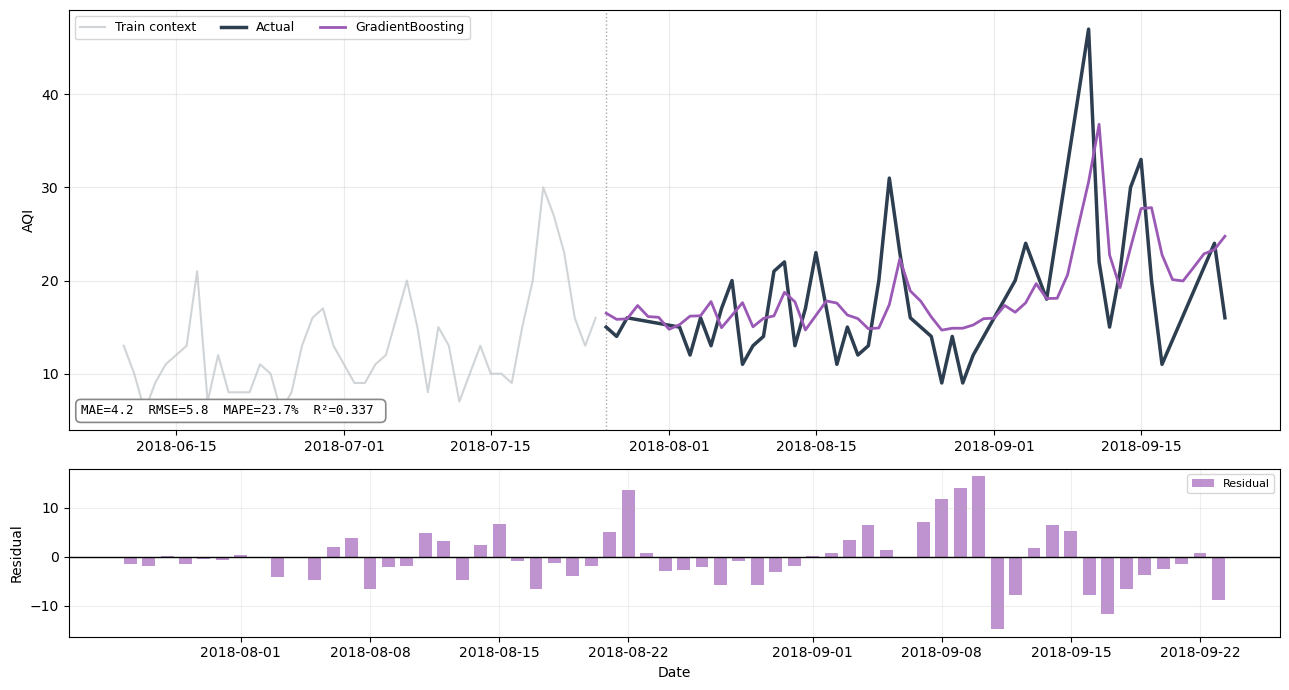

In [38]:
# Show first 3 folds in detail

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                        gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
tr_dates = pd.to_datetime(train_set.index)
ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
ax.plot(tr_dates[ctx], y_train[ctx],
        color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

te_dates = pd.to_datetime(test_set.index)
ax.plot(te_dates, y_test,
        color='#2C3E50', lw=2.5, label='Actual', zorder=5)


ax.plot(te_dates, pred,
        color=GD_MODEL_COLOR, lw=2, label=MODEL_NAME, zorder=6)

ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
ax.set_ylabel('AQI')


ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(alpha=0.25)

txt = (f"MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  "
        f"MAPE={m['MAPE(%)']:.1f}%  R²={m['R2']:.3f} ")
ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
        fontsize=9, va='bottom', family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

ax2 = axes[1]
ax2.bar(te_dates, y_test - pred,
        color=GD_MODEL_COLOR, alpha=0.65, label='Residual', width=0.7)
ax2.axhline(0, color='black', lw=1)
ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 7.3 Feature Importace  

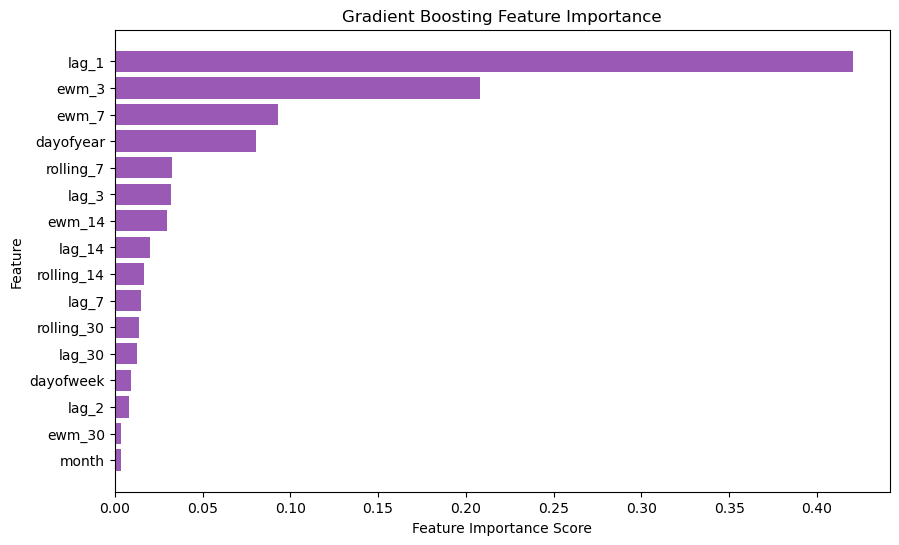

In [39]:
importances = gb.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
})


feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance_df)), feature_importance_df['importance'], align='center', color = GD_MODEL_COLOR)
plt.yticks(np.arange(len(feature_importance_df)), feature_importance_df['feature'])
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.title('Gradient Boosting Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

# 10.2 RandomForestRegressor

In [40]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

RF_MODEL_NAME = 'RandomForest'
RF_MODEL_COLOR = "#AE2754" 
RF_PARAMS = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
# Initialize the base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Setup the Search
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=RF_PARAMS,
    n_iter=10, 
    cv=3, 
    random_state=42, 
    scoring='neg_root_mean_squared_error',
    verbose=1
)

# Fit the search
print(f'Training {RF_MODEL_NAME}...')
random_search_rf.fit(X_train, y_train)

# Get the winner
rf_b = random_search_rf.best_estimator_
print(f"Best RF Params: {random_search_rf.best_params_}")

Training RandomForest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10}


In [41]:

rf_pred = np.clip(rf_b.predict(X_test), 0, None)

met_rf = get_metrics(y_test, rf_pred)

print(f'\n{RF_MODEL_NAME} Results:')
print(met_rf)


RandomForest Results:
{'MAE': 4.4166214467203035, 'RMSE': np.float64(6.022014507817094), 'MAPE(%)': 24.799318690935564, 'R2': 0.2815174412740651}


In [42]:
def plotting(MODEL_COLOR_, MODEL_NAME_, y_pred, metrics):

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                            gridspec_kw={'height_ratios': [2.5, 1]})

    ax = axes[0]
    tr_dates = pd.to_datetime(train_set.index)
    ctx = tr_dates >= tr_dates[-1] - pd.Timedelta(days=45)
    ax.plot(tr_dates[ctx], y_train[ctx],
            color='#BDC3C7', lw=1.5, alpha=0.7, label='Train context')

    te_dates = pd.to_datetime(test_set.index)
    ax.plot(te_dates, y_test,
            color='#2C3E50', lw=2.5, label='Actual', zorder=5)


    ax.plot(te_dates, y_pred,
            color=MODEL_COLOR_, lw=2, label=MODEL_NAME_, zorder=6)

    ax.axvline(te_dates[0], color='grey', lw=1, ls=':', alpha=0.7)
    ax.set_ylabel('AQI')


    ax.legend(fontsize=9, ncol=3, loc='upper left')
    ax.grid(alpha=0.25)

    txt = (f"MAE={metrics['MAE']:.1f}  RMSE={metrics['RMSE']:.1f} "
            f"MAPE={metrics['MAPE(%)']:.1f}%  R²={metrics['R2']:.3f} ")

    ax.annotate(txt, xy=(0.01, 0.03), xycoords='axes fraction',
            fontsize=9, va='bottom', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#888', lw=1.2))

    ax2 = axes[1]
    ax2.bar(te_dates, y_test - y_pred,
            color=MODEL_COLOR_, alpha=0.65, label='Residual', width=0.7)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Residual'); ax2.set_xlabel('Date')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

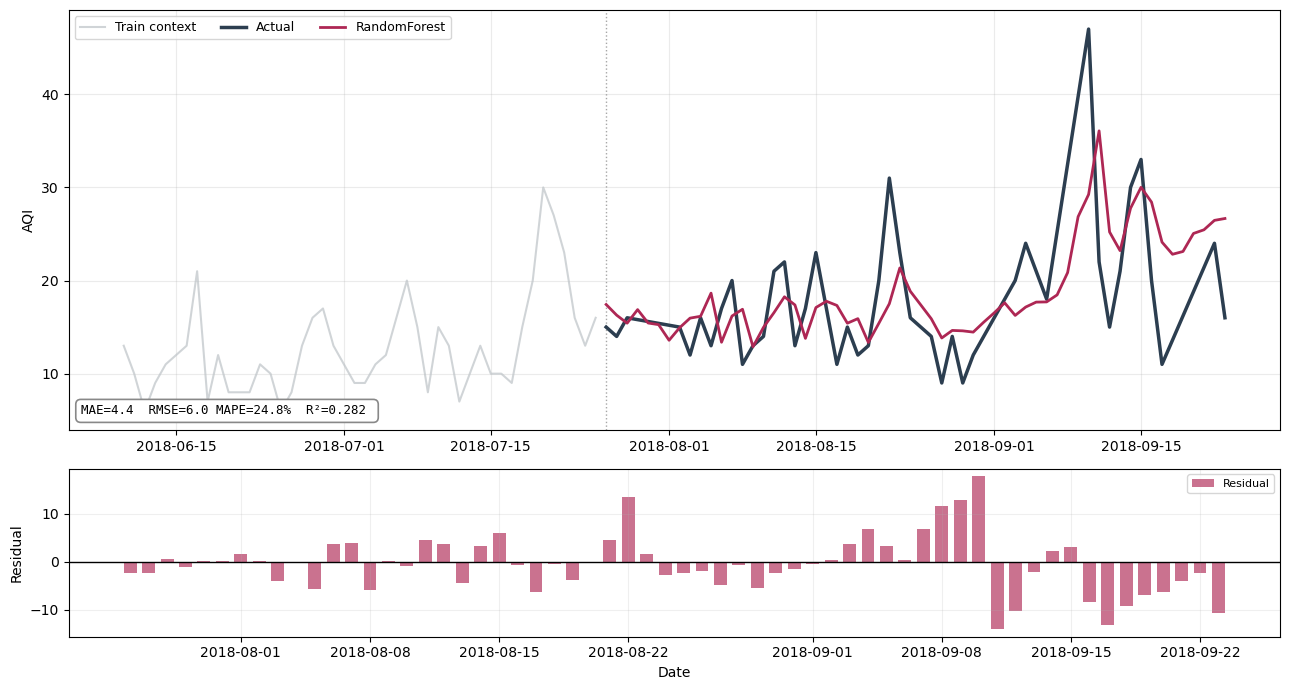

In [43]:
plotting(RF_MODEL_COLOR, RF_MODEL_NAME, rf_pred, met_rf)

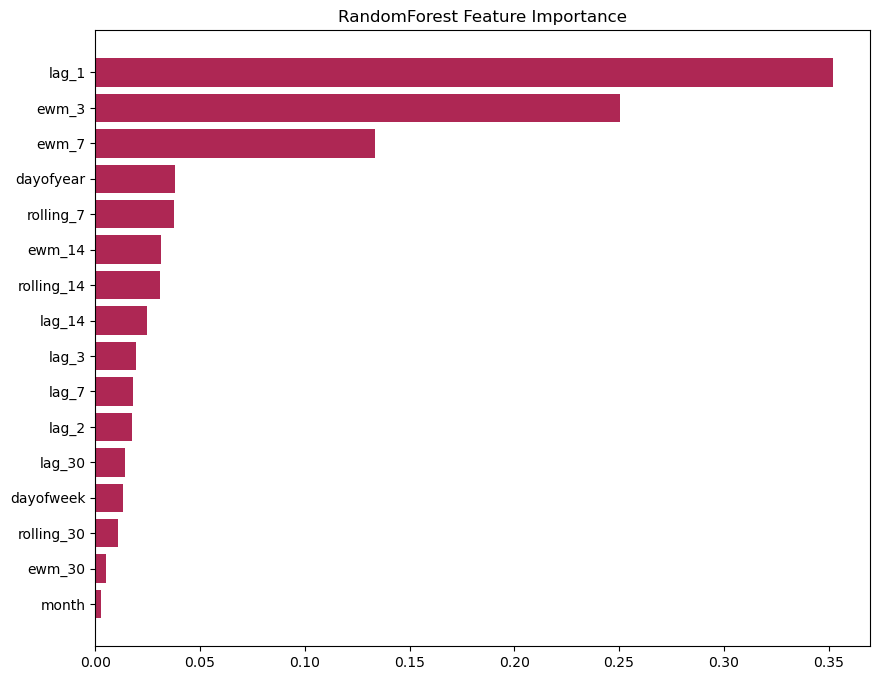

In [44]:
importances_rf = rf_b.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS, 
    'importance': importances_rf
}).sort_values(by='importance', ascending=False)


plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], 
         feature_importance_df['importance'], 
         color=RF_MODEL_COLOR)
plt.title(f'{RF_MODEL_NAME} Feature Importance')
plt.gca().invert_yaxis()
plt.show()